# Performance of big data problems I

[Matt Graham](https://matt-graham.github.io)
[](https://orcid.org/0000-0001-9104-7960)
(Centre for Advanced Research Computing)  
[Anastasis
Georgoulas](https://uk.linkedin.com/in/anastasis-georgoulas-265b12167)
[](https://orcid.org/0000-0001-7187-5443)

## Introduction: performance issues

Particularly when dealing with “big data”, the **size of the datasets**
and the **resources at our disposal** impose **limits** on what
computations we can realistically do.

Even when a solution for a problem exists in theory, in practice we are
bound by **limited resources**:

-   **Memory size**: can we keep everything we need in memory or do we
    need to write to the disk often?
-   **Processing power**: do we have enough processors to complete the
    computation in a reasonable time?
-   **Network bandwidth**: can we transfer everything we need?

## Learning outcomes

-   Identify key issues affecting the performance of data analysis
    tasks.
-   Use ‘big O’ notation to describe the scaling behaviour of
    algorithms.
-   Assess the benefits and drawbacks of using cloud services to scale
    computations.
-   Explain how we can break down and distribute large computational
    tasks.

## Problem scaling

Just because we can solve a problem on a small dataset doesn’t guarantee
that we can do it for large ones!

We must also consider the **scaling behaviour**: a dataset that is 10x
larger may require much more than 10x longer to process.

How an algorithm scales with the input size $N$ can be expressed in
asymptotic ‘big-O’ notation. For example:

-   $O(\log N)$: logarithmic in the size of the input.
-   $O(N)$: linear in the size of the input.
-   $O(N^2)$: quadratic in the size of the input.
-   $O(2^N)$: exponential in the size of the input.

## Problem scaling

The scaling behaviour of an algorithm can have a significant effect in
how it can handle large input data:

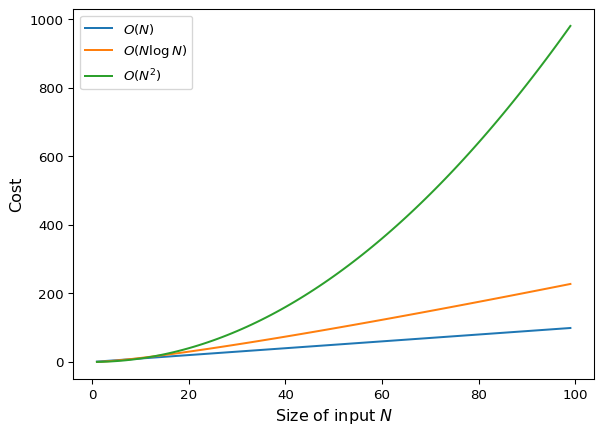

In [1]:
import matplotlib.pyplot as plt
import numpy as np

N = np.arange(1, 100)
fig, ax = plt.subplots()
ax.plot(N, N, label=r"$O(N)$")
ax.plot(N, N * np.log(N) / 2, label=r"$O(N \log N)$")
ax.plot(N, N**2 / 10, label=r"$O(N^2)$")
ax.set_xlabel("Size of input $N$", fontsize=12)
ax.set_ylabel("Cost", fontsize=12)
ax.legend()

## Improving resources

An obvious approach is to throw more resources at the problem: more
memory, faster networks, better processors. However:

-   We need to make sure it’s the right resource! Hence: **profiling**
    to understand resource consumption and bottlenecks.
-   More resource is not always available.
-   There may be other considerations e.g. energy consumption.

## Cloud computing

A paradigm that is becoming very popular recently is the use of **cloud
resources**: storage and computing resources held **remotely** and
**available on demand**.

We saw an example of this in Lecture 22 when downloading data from S3
(Amazon Web Services).

Major providers include *Amazon Web Services*, *Microsoft Azure* and
*Google Cloud Platform*.

## Cloud resources

Cloud providers offer a variety of resources, such as:

-   **Storage** (both files and various databases).
-   **Compute** (virtual machines, clusters for parallel computing).
-   **Services** (instances of popular programs like Tensorflow).

## Cloud computing advantages

This offers several advantages:

-   **Flexibility**: resources can be requested as and when needed, and
    can be scaled up or down depending on requirements.
-   **No maintenance**: updates are usually taken care of automatically
    by the provider.
-   **Ease of setup**: can use a service without worrying about setting
    up the infrastructure for it.

## Cloud computing disadvantages

However, there are also considerations to keep in mind:

-   **Cost**: can be difficult to predict.
-   **Limited customisability** compared to setting it up yourself.
-   **Geographical constraints** for data storage and processing
    (e.g. latency, personal data).

## Alternative approaches

Instead of using more or bigger resources, we could look at different
kinds of technologies and computational approaches:

-   Different language(s), libraries, algorithms.
-   Accelerator devices such as graphics processing units.
-   Parallel and distributed processing on multiple processors or a
    cluster.

These usually involve more work in adapting the solution but, if
effective, can yield important benefits.

A small resource (e.g. computer) can handle a small task:

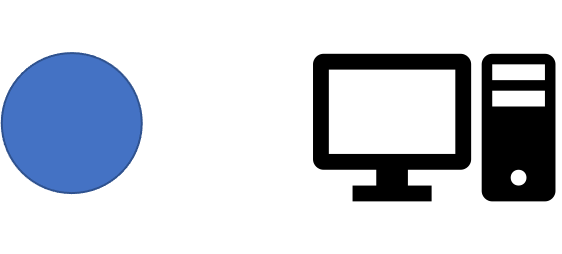

Faced with a large task, instead of increasing size of resource…

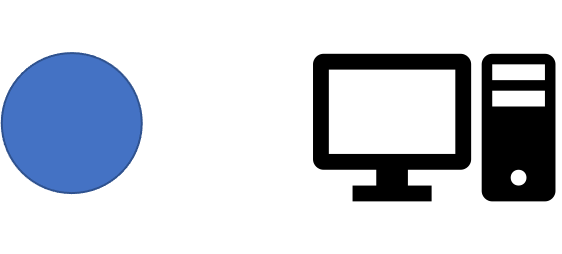

…break it down into smaller tasks:

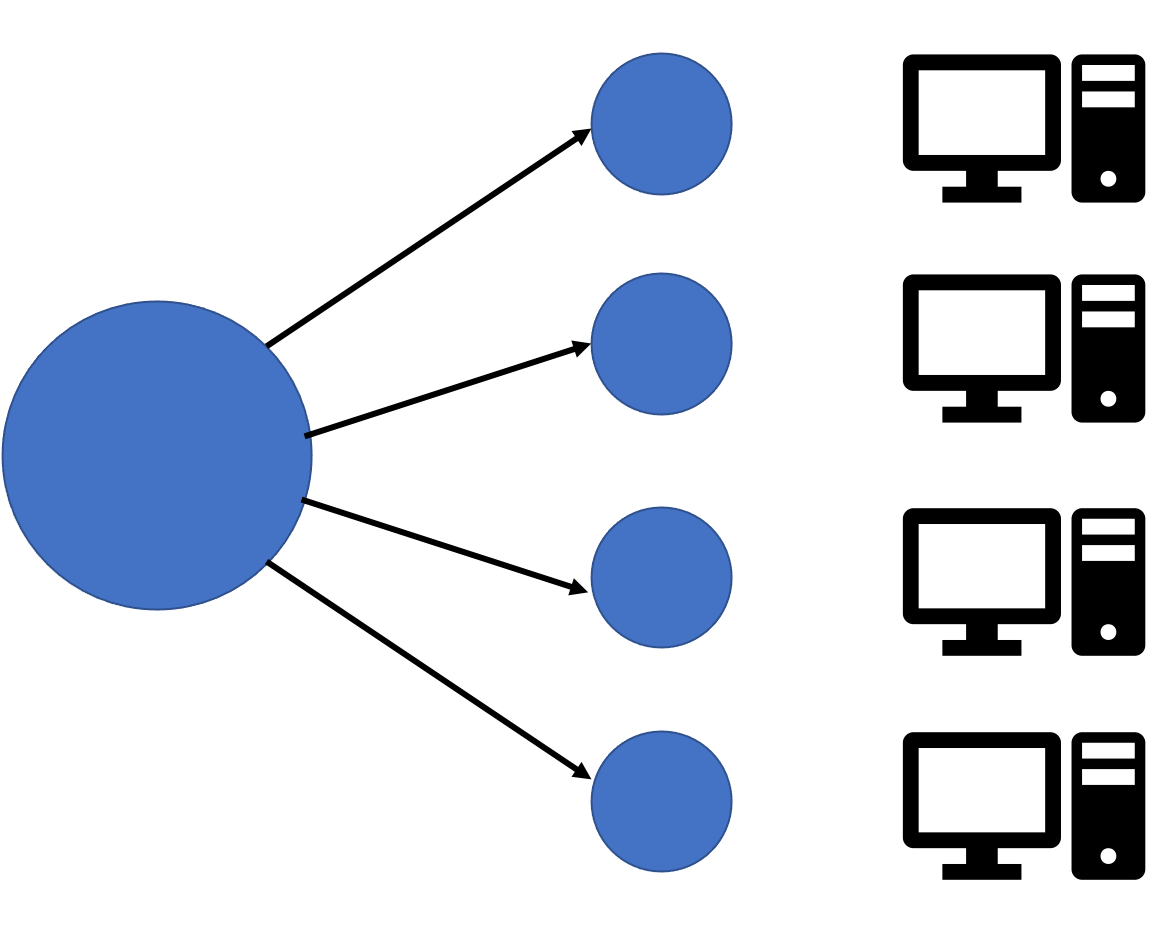

This is still not trivial:

-   Does the algorithm support it?
-   Can we efficiently combine results?
-   Is there support for doing it on the hardware?

## Changing algorithms

-   Reformulate in different steps that allow separation.
-   Maximize degree of parallelism.
-   Minimize communication.
-   Maintain correctness, avoid problems e.g. deadlock.

## MapReduce

How do we efficiently break down tasks and combine results?

<figure>
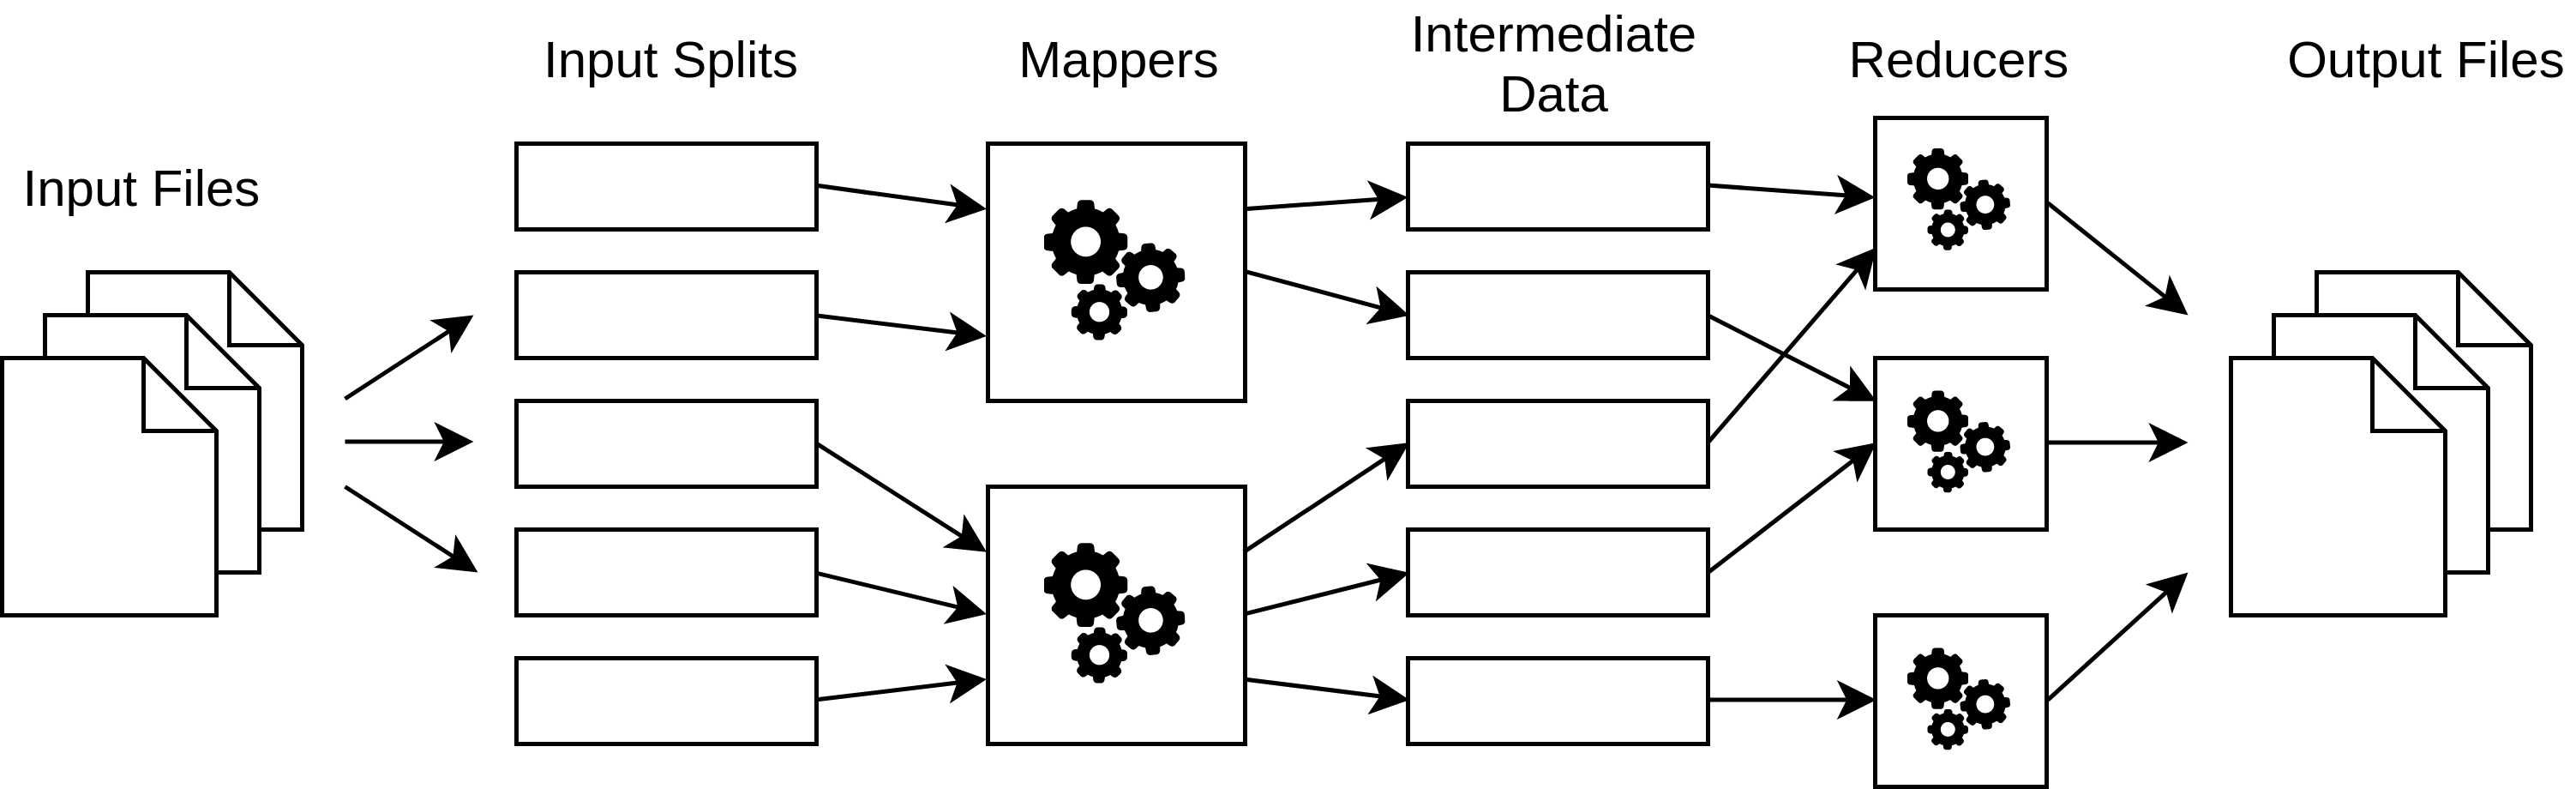
<figcaption aria-hidden="true">Image credit: Ben Congdon,
https://github.com/bcongdon/corral</figcaption>
</figure>

-   Break down data into smaller chunks.
-   Handle each chunk separately.
-   Group together results from smaller chunks.
-   Combine smaller results to form result from whole input.

## Example: MapReduce in Python

We can construct a very minimal (and non-parallelised) Python
implementation of a MapReduce ‘engine’ as follows

In [2]:
from collections import defaultdict

def mapreduce(data, mapper, reducer):
    grouper = defaultdict(list)
    for chunk in data:
        for key, value in mapper(chunk).items():
            grouper[key].append(value)
    return {
        k2: v2 
        for k1, v1 in grouper.items() 
        for k2, v2 in reducer(k1, v1).items()
    }

## Example: counting characters

As an example task imagine we want to count the number of occurrences of
each character in a sentence.

We can apply `mapreduce` by

-   using the *mapper* to assign a partial count of 1 to each character,
-   the *grouper* then gathers the partial counts for each character,
-   and the *reducer* sums the counts to outputs the counts per
    character.

In code:

In [3]:
character_counts = mapreduce(
    data="The quick brown fox jumps over the lazy dog.",
    mapper=lambda character: {character: 1},
    reducer=lambda character, partial_counts: {character: sum(partial_counts)}
)
print(character_counts)

{'T': 1, 'h': 2, 'e': 3, ' ': 8, 'q': 1, 'u': 2, 'i': 1, 'c': 1, 'k': 1, 'b': 1, 'r': 2, 'o': 4, 'w': 1, 'n': 1, 'f': 1, 'x': 1, 'j': 1, 'm': 1, 'p': 1, 's': 1, 'v': 1, 't': 1, 'l': 1, 'a': 1, 'z': 1, 'y': 1, 'd': 1, 'g': 1, '.': 1}

Or sorting the output:

In [4]:
print(dict(sorted(character_counts.items())))

{' ': 8, '.': 1, 'T': 1, 'a': 1, 'b': 1, 'c': 1, 'd': 1, 'e': 3, 'f': 1, 'g': 1, 'h': 2, 'i': 1, 'j': 1, 'k': 1, 'l': 1, 'm': 1, 'n': 1, 'o': 4, 'p': 1, 'q': 1, 'r': 2, 's': 1, 't': 1, 'u': 2, 'v': 1, 'w': 1, 'x': 1, 'y': 1, 'z': 1}

## Summary

-   The size of big data poses difficulties on conventional processing.
-   Using more powerful resources is a possibility, but sometimes a
    paradigm change is needed.
-   Conversion (such as by distributing computation) is not always
    straightforward but frameworks offer support.